## Characterization of within-scanner SC reliability

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage

from confounds import get_confounds

# Set the random seed the same way as in the defacing registered report (RR)
day = 231108 # day and time the journal published our HCPh stage 1 registered report
time = 105017
np.random.seed(day+time)

hcph_path = Path('/data/datasets/hcph-dataset')

### Simulate SC matrices with a set bias

We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman and hierarchical analyses capable of detecting such biases. Once the methodology is refined, we will apply it on the real HCPh data.

First, we generate a reference SC matrix on which we will later add noise to simulate between-session variability.

In [3]:
atlas_dim = 64  # Number of brain regions
scale = 0.01  # Mean track density
shape = 0.5  # Variability in density

# SC matrices typically follow a heavy-tailed distribution, with a few strong connections and many weak ones. 
# We thus use a log-normal distribution to simulate SC value.
SC_matrix = np.random.lognormal(mean=np.log(scale), sigma=shape, size=(atlas_dim, atlas_dim))

# Make it symmetric
SC_matrix = (SC_matrix + SC_matrix.T) / 2

# Set diagonal to 0 (no self-connections)
np.fill_diagonal(SC_matrix, 0)

print(SC_matrix.shape)
print(SC_matrix)
assert SC_matrix.shape == (atlas_dim, atlas_dim)

(64, 64)
[[0.         0.0104071  0.01055773 ... 0.01409003 0.00815167 0.01753186]
 [0.0104071  0.         0.01386371 ... 0.00683563 0.01134391 0.01011825]
 [0.01055773 0.01386371 0.         ... 0.0112412  0.01084525 0.01313846]
 ...
 [0.01409003 0.00683563 0.0112412  ... 0.         0.01790434 0.008778  ]
 [0.00815167 0.01134391 0.01084525 ... 0.01790434 0.         0.00919632]
 [0.01753186 0.01011825 0.01313846 ... 0.008778   0.00919632 0.        ]]


We will duplicate the reference SC matrix 36 times to simulate the 36 acquisition sessions adding some noise in the duplicates to simulate between-session variability.

In the first simulation, we will make the connections with a lower density more variable across sessions.

In [4]:
# Number of sessions
num_sessions = 36

# Create a 3D array to store the SC matrices for all sessions
SC_matrices = np.zeros((num_sessions, atlas_dim, atlas_dim))

# Identify the 20th percentile threshold for the connection values in the reference SC matrix
percentile_20_threshold = np.percentile(SC_matrix[SC_matrix > 0], 20)

# Add noise to each duplicate
for i in range(num_sessions):
    noise = np.random.normal(loc=0, scale=0.0005, size=SC_matrix.shape)
    higher_noise = np.random.normal(loc=0, scale=0.002, size=SC_matrix.shape)
    
    # Apply higher noise to connections below the 20th percentile to simulate higher variability in weaker connections
    noise[SC_matrix <= percentile_20_threshold] += higher_noise[SC_matrix <= percentile_20_threshold]
    
    SC_matrices[i, :, :] = SC_matrix + noise

    # SC cannot have negative values so if the value gets negative cast it to 0
    SC_matrices[i, :, :] = np.maximum(SC_matrices[i, :, :], 0)

print(SC_matrices.shape)
# Test whether the shape is as expected
assert SC_matrices.shape == (num_sessions, atlas_dim, atlas_dim)

(36, 64, 64)


### Prepare the SC matrices array for input in hierarchical clustering

To prepare the SC matrices array to input it in a hierarchical clustering analysis, we will keep only the lower triangle of each SC matrix and unravel it into a row vector.

In [5]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array([SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)])

print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(36, 2016)


### Perform hierarchical clustering to identify what sessions are more similar

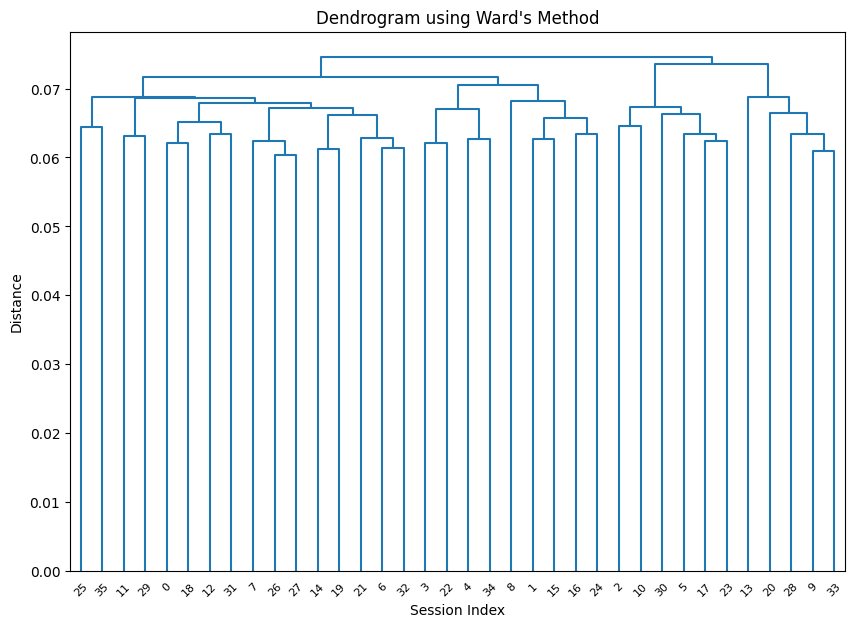

In [6]:
# Perform hierarchical clustering using Ward's method
linkage_matrix = linkage(SC_matrices_tril, method='ward')

# Generate and plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram using Ward's Method")
plt.xlabel("Session Index")
plt.ylabel("Distance")
plt.show()

### What factor has an influence on the sessions similarity?

We will retrieve a serie of confound factors for each session to investigate whether they influenced how similar sessions are; in other words whether they can explain a higher or lower variability across session. Specifically, we are interested in the time of day, the average head-motion summarized by framewise displacement (FD), room temperature at start and PE direction.

In [ ]:
confounds_df = get_confounds()
confounds_df = confounds_df[confounds_df["modality"] == "dwi"]
confounds_df.drop(columns=["task"], inplace=True)
confounds_df

# MISSING: retrieving head-motion and room temperature

,filename,acq_time,subject,session,modality,pe_dir,day_of_week,time_of_day
1,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T15:56:08.322500,001,pilot001,dwi,AP,Monday,16:00:00
2,sub-001/ses-pilot001/dwi/sub-001_ses-pilot001_...,2022-11-07T16:17:01.140000,001,pilot001,dwi,AP,Monday,16:00:00
5,sub-001/ses-pilot002/dwi/sub-001_ses-pilot002_...,2022-12-21T18:37:56.320000,001,pilot002,dwi,AP,Wednesday,19:00:00
6,sub-001/ses-pilot002/dwi/sub-001_ses-pilot002_...,2022-12-21T18:58:27.115000,001,pilot002,dwi,AP,Wednesday,19:00:00
13,sub-001/ses-pilot004/dwi/sub-001_ses-pilot004_...,2023-01-16T14:07:13.222500,001,pilot004,dwi,AP,Monday,14:00:00
...,...,...,...,...,...,...,...,...
2902,sub-001/ses-21201030/dwi/sub-001_ses-21201030_...,2024-09-04T22:27:18.955000,001,21201030,dwi,RL,Wednesday,22:00:00
2922,sub-001/ses-21202034/dwi/sub-001_ses-21202034_...,2024-09-05T00:18:22.455000,001,21202034,dwi,LR,Thursday,00:00:00
2947,sub-001/ses-21101060/dwi/sub-001_ses-21101060_...,2024-09-05T21:34:34.485000,001,21101060,dwi,RL,Thursday,22:00:00
2972,sub-001/ses-21202060/dwi/sub-001_ses-21202060_...,2024-09-05T23:14:55.437500,001,21202060,dwi,AP,Thursday,23:00:00
